<a href="https://colab.research.google.com/github/Tedodor423/bms-collab-notebooks/blob/main/stats/2.2_DataGeneratingDistributions/2.2.7_binomial_PMFandCDF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Binomial PMF and CDF

In this chapter we explored how we would simulate a binomial variable (the number of $k$ hits from $n$ trials) to estimate how often different outcomes occur (e.g., how often you will get 8 heads when flipping the coin 10 times). This is called a **numerical solution** or **simulation**.

There is also an **analytical solution** to calculating the expected number of hits if $k \sim \mathcal{B}(n,p)$. This means, there is an equation we can use to work out the exact probabilities. This equation is called the *probability mass function (PMF)*.

In this section we introduce:
* the PMF, which gives the probability of observeing a specific value of $k$
* The *cumulative density function (CDF)*, which gives the probability of observing a value less than or equal to $k$

In practice, you don't need to compute these equations by hand as there are built in functions in the `scipy.stats` library that does it for you. However it is useful to understand conceptually where the equations 'come from' (how they are derived), as covered in the lecture.

### Analytical vs numerical solutions

In this section we see The PMF and CDF are worked out from an equation rather than by random sampling
* Therefore the probability values (given by `stats.binom.pmf()` and `stats.binom.cdf()` will never change for given values of $n,p,k$)
* In contrast the values given by our simluations did vary slightly each time we ran our simulation

### Set up Python libraries

As usual, run the code cell below to import the relevant Python libraries



In [1]:
# Set-up Python libraries - you need to run this but you don't need to change it
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
import seaborn as sns
sns.set_theme(style='white')
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.simplefilter('ignore', category=FutureWarning)

## Binomial PMF

The probability mass function (PMF) tells us the probability of obtaining exactly $k$ hits out of $n$ trials.

The equation for the binomial PMF is as follows:

$$ p(k=K) = C^{n}_{k} p^k q^{n-k} $$

where:
* $p(k=K)$ is the probability of $K$ hits out of $n$ trials,
* $p$ is the probability of a hit on any given trial,
* $q=(1-p)$, and
* $C^{n}_{k} = \frac{n!}{k! (n-k)!}$ is the number of possible ways to get $k$ hits in $n$ tirals (sometimes called number of combinations). This reflects the fact that some pattern of hits and misses are more likely than others, for example, getting an even balance of hits and misses is more likely (as discussed in the lecture)

***Note:*** unsurprisingly, many people find the notation $p(k=K)$ (which is standard in statistical theory) confusing.

In this case $k$ is a *variable* (the number of hits) and $K$ is a specific value of it - so in a coin-tossing example, where we are interested in the chance of getting 8 heads out of 10 tosses, $k$=number of heads and $K$=8; we read $p(k=8)$ as *"the probability the number of heads is 8"*

### PMF (home-baked)

Let's implement the equation for the PMF ourselves and compare teh results to the simulated probability from the previous exercise (the proportion of times we got $k$=8 in 10000 simulated experiments.

In [4]:
# we need the Python library "math" for this code block!
import math

n=10 # values of n, p, k as in previous exercise
k=8
p=0.5

#Calculate the binomial coefficient n choose k (the number of wasy to get k hits in n trials)
n_choose_k = math.factorial(n) / (math.factorial(k) * math.factorial(n-k))

#Apply the binomial PMF formula - p(k) = C(n,k) * (p^k) * (1-p)^(n-k)
prob_k = n_choose_k  * ((p)**(k)) * ((1-p)**(n-k))

print(prob_k)

0.0439453125


Hopefully this should be roughly the same as the proportion of our 10,000 coin tosses in which k=8 (it wont exactly match, as the simulation was subject to random noise) - let's check!

In [13]:
n=10 # values of n, p, k as in previous exercise
k=8
p=0.5

ks = np.random.binomial(n, p, size=10000)
print(np.mean(ks==k))

0.0428


yep, not a bad match! - roughly 4% chance of getting exactly 8 heads - remember the exact value for our simulation will change every time we run it.

### PMF (built-in function)

We can also use a built-in function to give the PMF:

In [14]:
print(stats.binom.pmf(8,10,0.5))

0.04394531250000004


**Comprehension questions**
* Can you work out how to change this to get the probability of 7 heads out of 12 coin tosses?

In [15]:
print(stats.binom.pmf(7, 12, 0.5))

0.19335937500000003


* Can you change the code so that the probability of heads is 0.75?

In [16]:
print(stats.binom.pmf(7, 12, 0.75))

0.10324144363403315


## Binomial CDF

The CDF or cumulative distribution function tells us the probability of obtaining *less than or equal to* $k$ hits in $n$ trials. In other words, it gives the cumulative probability of all outcomes up to and including $k$.

As we have seen, we often want to know this *cumulative* probaility rather than just the chance of one exact value. For example, suppose we toss a fair coin 10 times and observe 8 heads, to judge if this result is surprising, and therefore whether the coin might be biased, we would ask

*"If the coin were fair, how likely would it be to get 8 or more heads out of 10 tosses"*

This questions asks for the probability of an outcome as extreme as, or more extreme than $k=8$. This includes no only 8 heads, but also 9 and 10, since we would also find those outcomes suspicious if were testing the fairness of the coin.

Below we will plot the pmf and cdf functions for every possible $k$ (0-10) out of 10 coin tosses

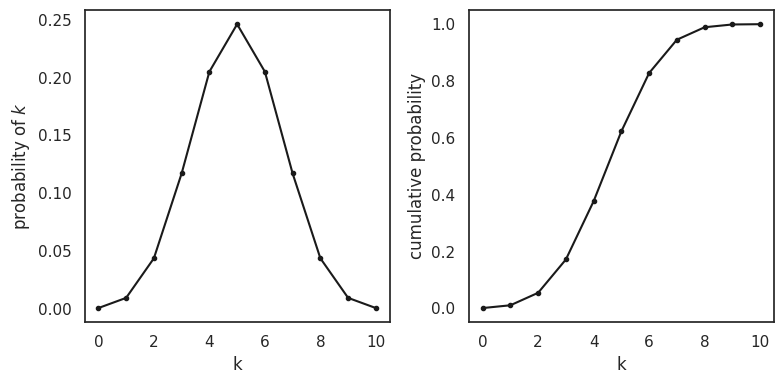

In [21]:
pmf = stats.binom.pmf(range(11),10,0.5)
cdf = stats.binom.cdf(range(11),10,0.5)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.plot(range(11), pmf, 'k.-')
plt.xlabel('k')
plt.ylabel('probability of $k$')

plt.subplot(1,2,2)
plt.plot(range(11), cdf, 'k.-')
plt.xlabel('k')
plt.ylabel('cumulative probability')


plt.tight_layout()
plt.show()

So above we can easily see the difference between the two plots. The PMF (left) shows us the probability of obtaining *exactly* a given value of $k$, where as the CDF (right) shows the probability of obtaining *at least* that value of $k$

* PMF(8) is the probability of obtaining exactly 8 heads ie $p(k==8)$, as confirmed above and on the plot this is around .04
* CDF(8) is the probability of obbtaining 8 or fewer heads, ie $p(k<=8)$, here we see that you have a very high chance of getting at least 8 heads.

### Area under the PMF sums to 1

The probability of all possibe outcomes must sum to 1.

This means:
* CDF(10) = 1, because it is certain we'll get 10 or fewer heads in 10 tosses

The CDF always gives us the area under the PMF curve to the *left* of a given value, for example CDF(8) gives us $p(k<=8)$.

If we want to know the probability of getting *more* than (say) 7 heads (i.e., the probability of getting 8,9, or 10), then we use the fact that the area under the curve sums to 1:

$$p(k>=8) = 1 - p(k<8) = 1-p(k<=7)$$

$$or$$

$$p(k>=8) = 1 - cdf(7)$$


So to calculate the probability of getting more than 7 heads in python you can use the folowing code

In [23]:
print(1 - stats.binom.cdf(7,10,.5))

0.0546875


**Be Careful with the inequalities!**

Since $k$ only takes integer values the following are equivalent:

$p(k<8) = p(k<=7)$
  
$and$

$p(k>=8) = p(k>7)$


So when using the function `stats.binom.cdf(x)`, remember this is always gives you:
$p(k<=x)$

**Comprehension questions**

* You will need to choose the correct function (`stats.binom.pmf()` or `stats.binom.cdf()` and the right values of n,p,k to match the numerical answer given in the comments of each cell

In [24]:
# Find the probability of exactly 9 heads out of 12 coin tosses,
# when the probability of heads is 0.75

stats.binom.pmf(9, 12, 0.75)

# answer = 0.2581

np.float64(0.2581036090850829)

In [26]:
# Find the probability of exactly 5 tails out of 6 coin tosses,
# when the probability of heads is 0.6

stats.binom.pmf(5, 6, 0.4)

# answer = 0.0386

np.float64(0.03686400000000002)

In [30]:
# Find the probability of at least 7 heads out of 20 coin tosses,
# when the probability of heads is 0.55

1 - stats.binom.cdf(6, 20, 0.55)


# answer = 0.9785

np.float64(0.9785856443569791)

In [31]:
# Find the probability of fewer than 10 heads out of 20 coin tosses,
# when the probability of heads is 0.4

stats.binom.cdf(9, 20, 0.4)

# answer = 0.7553

np.float64(0.7553372033163932)

In [33]:
# Find the probability of more than 10 tails out of 15 coin tosses,
# when the probability of heads is 0.3


1 - stats.binom.cdf(10, 15, 0.7)

# answer = 0.515

np.float64(0.5154910592268429)